In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
df = pd.read_csv("customer_churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.shape

(7043, 21)

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [7]:
# data cleaning
# check null value
df.isnull().sum

<bound method NDFrame._add_numeric_operations.<locals>.sum of       customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0          False   False          False    False       False   False   
1          False   False          False    False       False   False   
2          False   False          False    False       False   False   
3          False   False          False    False       False   False   
4          False   False          False    False       False   False   
...          ...     ...            ...      ...         ...     ...   
7038       False   False          False    False       False   False   
7039       False   False          False    False       False   False   
7040       False   False          False    False       False   False   
7041       False   False          False    False       False   False   
7042       False   False          False    False       False   False   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  

In [8]:
#remove duplicate 
df.drop_duplicates(inplace=True)

In [9]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [11]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
#check blank space exist 
(df['TotalCharges'] == " ").sum()

0

In [13]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [14]:
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

### SQLite help to run sql queries inside jupiter
#### create sql database

In [15]:
conn = sqlite3.connect("churn_analysis.db")

In [16]:
# convert pandas dataframe into sql table

df.to_sql("customers",conn,if_exists="replace",index=False)

7043

In [17]:
# verify table exists
query = """
SELECT *
FROM customers
LIMIT 5
"""
pd.read_sql(query, conn)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Total customers(count all row from customer table)
query = """
SELECT COUNT(*) AS TotalCustomers 
FROM customers
"""
pd.read_sql(query, conn)

,TotalCustomers
0,7043


### The dataset contain 7043 telecom customers for churn analysis

In [19]:
# churn count query(only select customers who left)
query = """
SELECT COUNT(*) AS ChurnCustomers
FROM customers
WHERE Churn='Yes'
"""

pd.read_sql(query, conn)

,ChurnCustomers
0,1869


### Inference:
Out of 7043 customers, 1869 customers have churned, indicating a noticeable customer loss for the company.

In [20]:
# churn rate query
query = """
SELECT 
ROUND(
SUM(
CASE
WHEN Churn='Yes'
THEN 1
ELSE 0
END
)*100.0/COUNT(*),
2
) AS ChurnRate
FROM customers
"""

pd.read_sql(query, conn)

,ChurnRate
0,26.54


### Inference:
The telecom company has a churn rate of 26.54%, which means around one-fourth of customers have left the service.

In [21]:
# contract wise churn analysis(identify which contract customer leave most)
query = """
SELECT Contract,
COUNT(*) AS TotalCustomers
FROM customers
WHERE Churn='Yes'
GROUP BY Contract
ORDER BY TotalCustomers DESC
"""

pd.read_sql(query, conn)

,Contract,TotalCustomers
0,Month-to-month,1655
1,One year,166
2,Two year,48


### Inference:
Customers with month-to-month contracts have the highest churn count (1655), while customers with long-term contracts 
show much lower churn. This suggests long-term contracts improve customer retention.

In [22]:
#payment method churn(payment affect churn)
query = """
SELECT PaymentMethod,
COUNT(*) AS ChurnCustomers
FROM customers
WHERE Churn='Yes'
GROUP BY PaymentMethod
ORDER BY ChurnCustomers DESC
"""

pd.read_sql(query, conn)

,PaymentMethod,ChurnCustomers
0,Electronic check,1071
1,Mailed check,308
2,Bank transfer (automatic),258
3,Credit card (automatic),232


### Inference:
Customers using electronic check payment methods show the highest churn count (1071), indicating possible 
dissatisfaction or higher risk among these users.

In [23]:
# average monthly charges(analyze pricing impact)
query = """
SELECT
AVG(MonthlyCharges)
AS AverageMonthlyCharge
FROM customers
"""

pd.read_sql(query, conn)

,AverageMonthlyCharge
0,64.761692


### Inference:
The average monthly charge of customers is 64.76, providing insight into the company’s average service pricing.

In [24]:
#churn vs monthly charges
query = """
SELECT
AVG(MonthlyCharges)
AS AverageMonthlyCharge
FROM customers
"""

pd.read_sql(query, conn)

,AverageMonthlyCharge
0,64.761692


### Inference:
Monthly charges appear to influence customer churn behavior and require further detailed analysis using
visualization techniques.

In [25]:
# high risk customers
query = """
SELECT customerID,
tenure,
MonthlyCharges,
Contract
FROM customers
WHERE tenure < 12
AND MonthlyCharges > 70
"""

pd.read_sql(query, conn)

,customerID,tenure,MonthlyCharges,Contract
0,9237-HQITU,2,70.70,Month-to-month
1,9305-CDSKC,8,99.65,Month-to-month
2,4929-XIHVW,2,95.50,Month-to-month
3,8168-UQWWF,11,97.85,Month-to-month
4,7760-OYPDY,2,80.65,Month-to-month
...,...,...,...,...
821,1980-KXVPM,3,75.05,Month-to-month
822,0723-DRCLG,1,74.45,Month-to-month
823,1122-JWTJW,1,70.65,Month-to-month
824,6894-LFHLY,1,75.75,Month-to-month


### Inference:
A total of 826 customers fall into the high-risk category based on low tenure and high monthly charges.
These customers may require retention-focused strategies.

In [26]:
# senior citizen churn
query = """
SELECT SeniorCitizen,
COUNT(*) AS ChurnCustomers
FROM customers
WHERE Churn='Yes'
GROUP BY SeniorCitizen
"""

pd.read_sql(query, conn)

,SeniorCitizen,ChurnCustomers
0,0,1393
1,1,476


### Inference:
Non-senior citizens contribute more to total churn count due to larger population size, 
while senior citizens also represent a significant portion of churned customers.

## Feature engineering

In [27]:
## create customer category
df['CustomerType'] = df['tenure'].apply(lambda x:'Loyal'if x > 24 else 'New')

In [28]:
df[['tenure','CustomerType']].head()

,tenure,CustomerType
0,1,New
1,34,Loyal
2,2,New
3,45,Loyal
4,2,New


### Inference:
Customers were categorized into Loyal and New groups based on tenure to better understand customer retention behavior.

In [29]:
## create charge category
df['ChargeCategory'] = pd.cut(
    df['MonthlyCharges'],
    bins=[0,35,70,120],
    labels=['Low','Medium','High']
)

In [30]:
df[['MonthlyCharges','ChargeCategory']].head()

,MonthlyCharges,ChargeCategory
0,29.85,Low
1,56.95,Medium
2,53.85,Medium
3,42.30,Medium
4,70.70,High


### Inference:
Monthly charges were grouped into Low, Medium, and High categories to analyze pricing impact on customer churn.

In [31]:
# create average spend feature
df['AvgSpendPerMonth'] = (df['TotalCharges']/ df['tenure'].replace(0,1))

In [32]:
df[['TotalCharges','tenure','AvgSpendPerMonth']].head()

,TotalCharges,tenure,AvgSpendPerMonth
0,29.85,1,29.850000
1,1889.50,34,55.573529
2,108.15,2,54.075000
3,1840.75,45,40.905556
4,151.65,2,75.825000


### Inference:
Average monthly spending was calculated to better understand customer value and spending behavior.

In [33]:
# check new columns
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerType,ChargeCategory,AvgSpendPerMonth
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,Low,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,Loyal,Medium,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,Medium,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Loyal,Medium,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,High,75.825000


### EDA & VISUALIZATION

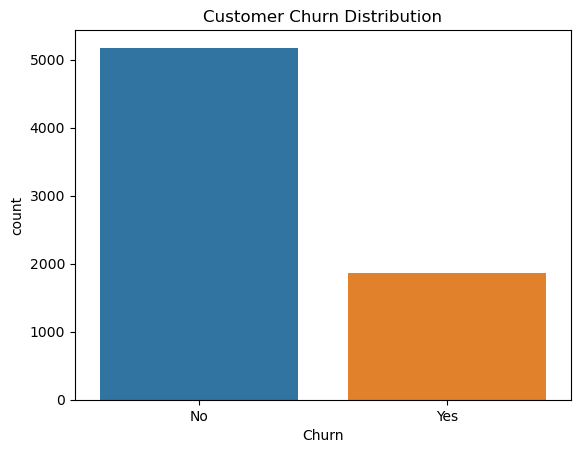

In [34]:
# churn distribution
sns.countplot(x='Churn',data=df)
plt.title("Customer Churn Distribution")
plt.savefig("../screenshots/churn_distribution.png")
plt.show()

### Insight:
The number of non-churn customers is higher than churn customers, but the churn count
is still significant for business concern.

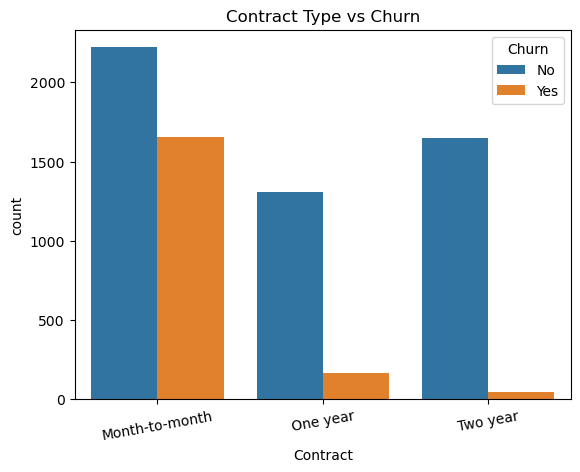

In [35]:
# contact type vs churn
sns.countplot(x='Contract',hue='Churn',data=df)
plt.title("Contract Type vs Churn")
plt.xticks(rotation=10)
plt.savefig("../screenshots/contact_type vs churn.png")
plt.show()

### Insight:
Customers with month-to-month contracts have significantly higher churn compared to customers with yearly contracts.

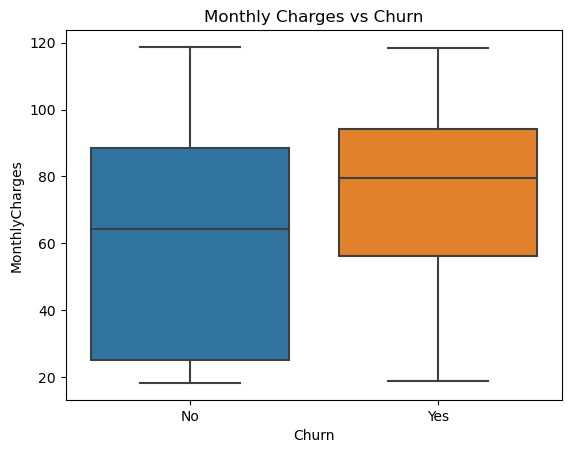

In [36]:
# Monthly charges vs churn
sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df)

plt.title("Monthly Charges vs Churn")
plt.savefig("../screenshots/monthlycharges vs churn.png")
plt.show()

### Insight:
Customers with higher monthly charges tend to churn more frequently than customers with lower monthly charges.

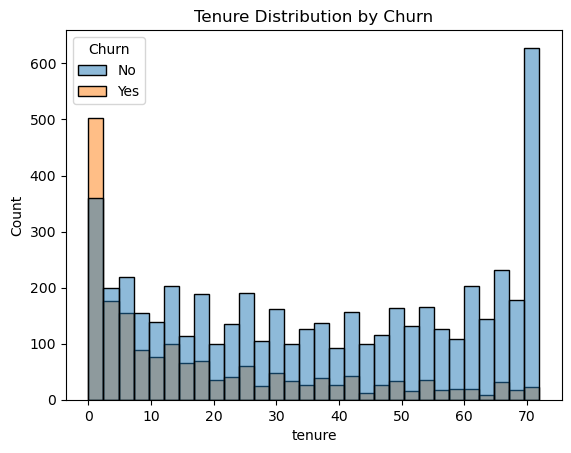

In [37]:
# tenure distribution
sns.histplot(
    data=df,
    x='tenure',
    hue='Churn',
    bins=30)

plt.title("Tenure Distribution by Churn")
plt.savefig("../screenshots/tenure distribution by churn.png")
plt.show()

### Insight:
Customers with lower tenure show higher churn behavior, while long-term customers are more likely to stay.

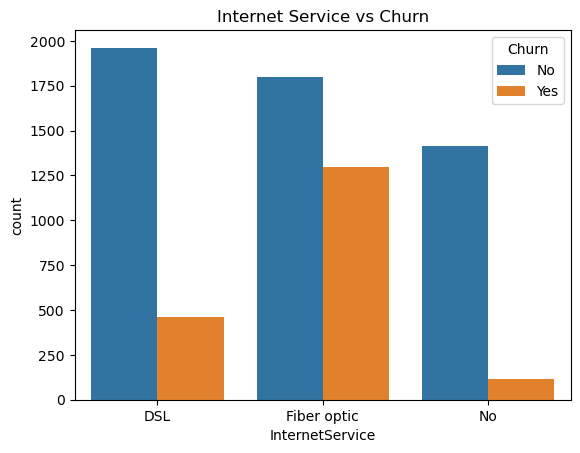

In [38]:
# Internet service vs churn
sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title("Internet Service vs Churn")
plt.savefig("../screenshots/Internet service vs churn.png")
plt.show()

### Insight:
Fiber optic internet users show higher churn compared to other internet service categories.

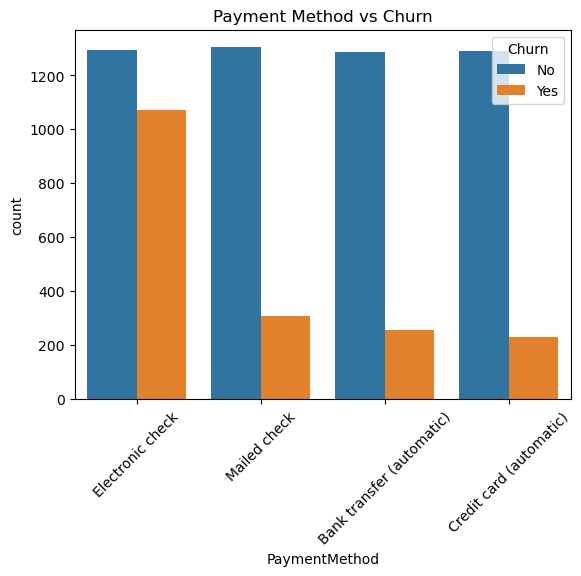

In [39]:
## payment method vs churn
sns.countplot(x='PaymentMethod',hue='Churn',data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.savefig("../screenshots/payment method vs churn.png")
plt.show()

### Insight:
Electronic check users show higher churn behavior compared to other payment methods.

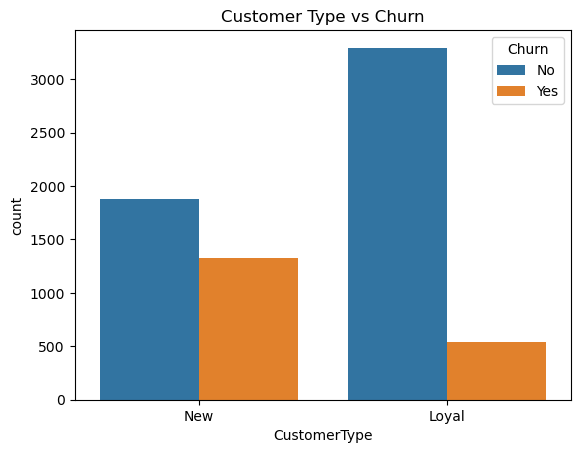

In [40]:
## customer type vs churn
sns.countplot(
    x='CustomerType',
    hue='Churn',
    data=df
)

plt.title("Customer Type vs Churn")
plt.savefig("../screenshots/customer_type vs churn.png")
plt.show()

### Insight:
New customers have higher churn rates, while loyal customers demonstrate better retention.

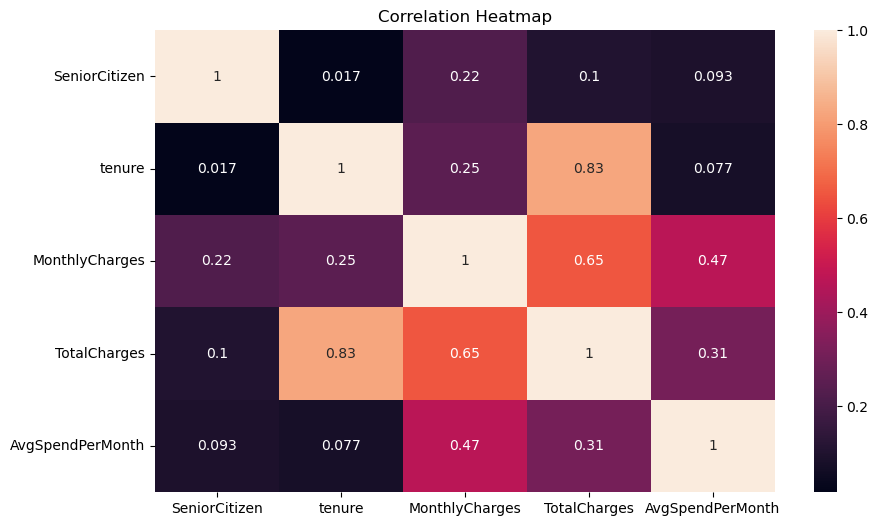

In [41]:
# correlation hearmap
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True
)

plt.title("Correlation Heatmap")
plt.savefig("../screenshots/correlation heatmap.png")
plt.show()

### Insight:
Monthly charges and total charges show positive correlation, while tenure indicates stronger customer retention behavior.

# Final Business Insights
## 
1. The telecom company has a churn rate of 26.54%, indicating significant customer loss.

2. Customers with month-to-month contracts show the highest churn behavior compared to yearly contracts.

3. Customers with high monthly charges are more likely to churn.

4. New customers demonstrate higher churn compared to loyal customers.

5. Electronic check payment users have higher churn rates.

6. Customers with lower tenure tend to leave earlier, while long-term customers show stronger retention.

7. Fiber optic internet users display relatively higher churn behavior.

# Business Recommendations
###
1. Introduce attractive offers for month-to-month customers to encourage long-term contracts.

2. Provide loyalty rewards and retention benefits for long-term customers.

3. Review pricing strategies for customers with high monthly charges.

4. Improve onboarding experience for new customers to reduce early churn.

5. Improve customer support for electronic check users.

6. Develop targeted retention campaigns for high-risk customers.

In [43]:
# conn.close()

### Machine Learning : Customer Churn Analysis

In [112]:
# Create ML Dataset Copy
df_ml = df.copy()
df_ml.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerType,ChargeCategory,AvgSpendPerMonth
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,Low,29.850000
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,Loyal,Medium,55.573529
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,Medium,54.075000
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Loyal,Medium,40.905556
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,High,75.825000


### Insight:
A separate copy of the dataset was created for machine learning to preserve the original dataset used in EDA and SQL analysis.

In [113]:
# Feature Selection
df_ml.drop('customerID', axis=1, inplace=True)

## Insight:
CustomerID was removed because it is a unique identifier and does not contribute to churn prediction

In [114]:
df_ml.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerType,ChargeCategory,AvgSpendPerMonth
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,New,Low,29.850000
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,No,Loyal,Medium,55.573529
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,New,Medium,54.075000
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Loyal,Medium,40.905556
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,New,High,75.825000


In [115]:
print(df_ml['Churn'].isnull().sum())
print(df_ml['Churn'].unique())

0
['No' 'Yes']


In [116]:
## Target Variable Encoding
df_ml['Churn'] = df_ml['Churn'].map({
    'No': 0,
    'Yes': 1
})
df_ml['Churn'].value_counts()

0    5174
1    1869
Name: Churn, dtype: int64

### Insight:
The target variable was converted into numerical format for machine learning modeling.

In [117]:
# Categorical Feature Encoding
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in df_ml.select_dtypes(include=['object']).columns:
    
    label_encoders[column] = LabelEncoder()

    df_ml[column] = label_encoders[column].fit_transform(
        df_ml[column]
    )

df_ml.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,CustomerType,ChargeCategory,AvgSpendPerMonth
0,0,0,1,0,1,0,1,0,0,2,...,0,0,1,2,29.85,29.85,0,1,Low,29.850000
1,1,0,0,0,34,1,0,0,2,0,...,0,1,0,3,56.95,1889.50,0,0,Medium,55.573529
2,1,0,0,0,2,1,0,0,2,2,...,0,0,1,3,53.85,108.15,1,1,Medium,54.075000
3,1,0,0,0,45,0,1,0,2,0,...,0,1,0,0,42.30,1840.75,0,0,Medium,40.905556
4,0,0,0,0,2,1,0,1,0,0,...,0,0,1,2,70.70,151.65,1,1,High,75.825000


### Insight:
Categorical features were encoded into numerical values so that machine learning algorithms could process them.

In [118]:
# Convert category column into string

df_ml['ChargeCategory'] = df_ml['ChargeCategory'].astype(str)

# Encode all categorical columns

from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in df_ml.select_dtypes(include=['object']).columns:

    label_encoders[column] = LabelEncoder()

    df_ml[column] = label_encoders[column].fit_transform(df_ml[column])

# Verify data types

print(df_ml.dtypes)

gender                int32
SeniorCitizen         int64
Partner               int32
Dependents            int32
tenure                int64
PhoneService          int32
MultipleLines         int32
InternetService       int32
OnlineSecurity        int32
OnlineBackup          int32
DeviceProtection      int32
TechSupport           int32
StreamingTV           int32
StreamingMovies       int32
Contract              int32
PaperlessBilling      int32
PaymentMethod         int32
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
CustomerType          int32
ChargeCategory        int32
AvgSpendPerMonth    float64
dtype: object


In [119]:
# Feature and Target Separation
X = df_ml.drop('Churn', axis=1)

y = df_ml['Churn']


print(X.shape)
print(y.shape)

(7043, 22)
(7043,)


## Insight
The dataset contains 7043 customer records.
A total of 22 predictor variables were selected for churn prediction.
The target variable (Churn) contains one value per customer record.

In [120]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 22)
(1409, 22)
(5634,)
(1409,)


### Insight
80% of the data (5634 records) was used for model training.
20% of the data (1409 records) was reserved for testing.
The split allows evaluation of model performance on unseen customer data.

In [121]:
#print(df_ml.dtypes)

In [136]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# print(X_train[:5])

### Insight:
Feature scaling was performed to standardize feature values and improve model performance.

In [126]:
# Logistic Regression Model Training
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train,
    y_train
)
# print("Model Trained Successfully")

LogisticRegression(max_iter=1000)

## Insight:
Logistic Regression was selected because customer churn prediction is a binary classification problem.

In [127]:
# Model Prediction
y_pred = model.predict(X_test)
print(y_pred[:20])

[1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0]


### Insights
The model generated churn predictions for unseen customers.
Value 1 represents customers likely to churn.
Value 0 represents customers likely to remain with the company.

In [128]:
#  Accuracy Score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8161816891412349


## Insight
The model correctly classified approximately 82% of customer records.
This indicates good baseline performance for a Logistic Regression model.

In [138]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[937  99]
 [160 213]]


### Insight
937 customers were correctly identified as non-churn customers.
213 customers were correctly identified as churn customers.
99 customers were incorrectly predicted as churn.
160 churn customers were missed by the model.
The model performs well overall but can still improve churn detection.

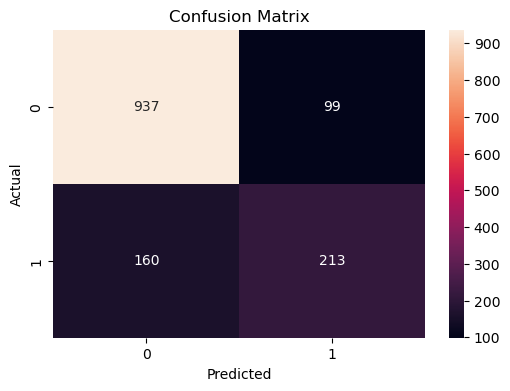

In [130]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [131]:
# Classification Report
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.88      1036
           1       0.68      0.57      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



### Insight
Precision of 68% indicates that most predicted churn customers were correctly identified.
Recall of 57% shows that the model detected over half of actual churn customers.
F1-score of 62% demonstrates a balanced trade-off between precision and recall.

In [132]:
# Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

feature_importance.sort_values(
    by='Coefficient',
    ascending=False
).head(10)

,Feature,Coefficient
17,MonthlyCharges,0.797002
18,TotalCharges,0.646328
7,InternetService,0.223668
15,PaperlessBilling,0.177220
6,MultipleLines,0.070958
20,ChargeCategory,0.066673
1,SeniorCitizen,0.066133
16,PaymentMethod,0.060619
2,Partner,0.036958
13,StreamingMovies,0.025052


### Insight
MonthlyCharges is the strongest factor increasing churn probability.
Customers with higher charges are more likely to leave the company.
Internet-related services and billing methods also influence churn behavior.

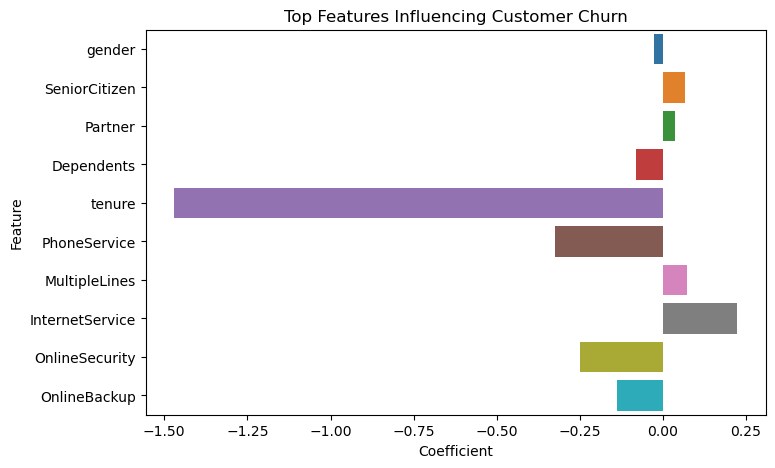

In [133]:
# Feature Importance Visualization
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title(
    "Top Features Influencing Customer Churn"
)

plt.show()

In [134]:
## Top Churn Risk Factors
feature_importance.sort_values(
    by='Coefficient',
    ascending=False
).head(10)
feature_importance.sort_values(
    by='Coefficient',
    ascending=True
).head(10)


,Feature,Coefficient
4,tenure,-1.471609
14,Contract,-0.580644
5,PhoneService,-0.325629
8,OnlineSecurity,-0.250668
11,TechSupport,-0.221996
21,AvgSpendPerMonth,-0.160427
9,OnlineBackup,-0.138437
19,CustomerType,-0.104207
3,Dependents,-0.081674
10,DeviceProtection,-0.075920


### Insight
Tenure is the strongest retention factor.
Long-term customers are significantly less likely to churn.
Customers with contracts, online security, and technical support services show better retention behavior.

### Machine Learning Insights

-Logistic Regression achieved 81.62% accuracy in predicting customer churn.

-MonthlyCharges emerged as the most influential churn-driving factor

-Customers paying higher charges showed greater churn probability

-Longer customer tenure significantly reduced churn likelihood

-Long-term contract customers demonstrated stronger retention behavior

-OnlineSecurity and TechSupport services contributed positively to customer retention

-The model can help identify high-risk customers and support proactive retention strategies

### Business Impact of Machine Learning

The predictive model can be integrated into telecom operations to identify customers at risk of leaving.

Retention offers can be targeted toward high-risk customers.

This can reduce churn and improve customer lifetime value.

## Project Conclusion

This project analyzed customer churn behavior in a telecom company using SQL, Python, Feature Engineering, Data Visualization, and Machine Learning techniques.

The analysis revealed that customers with month-to-month contracts, higher monthly charges, electronic check payments, and shorter tenure were more likely to churn.

Several engineered features such as CustomerType, ChargeCategory, and AvgSpendPerMonth provided additional insights into customer behavior.

A Logistic Regression model was developed to predict customer churn and achieved an accuracy of 81.62%. Feature importance analysis identified MonthlyCharges, TotalCharges, and InternetService as major churn drivers, while tenure, contract type, technical support, and online security were key retention factors.

The findings can help telecom companies identify high-risk customers, improve retention strategies, and make data-driven business decisions.
